## 3DoF Entry VTOL w/o Aoa SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.problem                         as prob
import trajopt.utils.config_loader                  as cfg
import trajopt.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc

from trajopt.analysis.trajplots import *

from custom_functions_dan import max_q_nonjax, max_Q_nonjax, max_load_nonjax, terminal_cost



setup problem and run SCP

In [2]:
example_name = "vtol1_entry_3dof"
nominal_config  = cfg.load_configs(example_name)

# either generate mc variations from yamls or load existing saved mc variations
gen_mc_variations    = 1

# save mc variations to file (specificy a name for this set of mc variations as well)
save_mc_variations   = 0
mc_name = "mc1"

# save scenario data to file (save the scenario data struct)
save_scenario_data   = 0

# run mc analysis loop
# TODO(Carlos and  Dan):  shouldn't need to return problem, just scenario data, something below depends on it though (this is the most recent problem instance)
scenario_data, problem = mc.run_mc_analysis(example_name, nominal_config, gen_mc_variations, save_mc_variations, save_scenario_data, mc_name)

scales: 
d: 6378137.0000, t: 806.3293, m: 104305.0000, v: 7910.0900, a: 9.8100, f: 1023232.0500, ang: 57.2958, angv: 0.0711
Initial guess time: 0.2541213750082534 seconds
Cost initial: 0.11051444205607251
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: vtol: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
---------------------------------------------------------------------------------------------------

/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    02699.8   |   0007.0  |   2640.3   |   -2.2    |      -12.0      |    -02.6    |     -12.0   |    optimal    |   1788.88   |  559.7
     02     |    00011.2   |   0010.1  |   0000.9   |   -1.9    |      -12.0      |    -03.3    |     -07.6   |    optimal    |   1694.37   |  579.6
     03     |    00006.0   |   0011.7  |   0001.0   |   -1.9    |      -12.0      |    -03.4    |     -08.5   |    optimal    |   1690.86   |  533.4
     04     |    00007.1   |   0011.2  |   0000.8   |   -3.9    |      -12.0      |    -03.6    |     -12.0   |    optimal    |   1699.61   |  503.2
     05     |    00007.9   |   0010.3  |   0000.9   |   -4.0    |      -12.0      |    -03.8    |     -12.0   |    optimal    |   1704.96   |  482.7
     06     |    00008.5   |   0010.0  |   0000.8   |   -4.4    |      -12.0      |    -04.0    |     -12.0   |    optimal    |   1706.80   |  476.9
     07     |    00009.0   |   0010.2  |   0000.8   |   -4.5    |      -12.0      |    -04.0    |     -12.

mc analysis

In [3]:
# file = '~/masters-link/ACL/prototypes/trajopt/src/trajopt/examples/vtol1_entry_3dof/data/statistics/mc1.txt' # Example file
# analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

# Can run without filename if you don't want to save LaTeX tables
analysis = stats.analyze_quality_metrics(scenario_data)

Extracting data from runs...
Computing statistics across runs...
Generating statistic tables...
Plotting tables...

=== No. of Iteration ===

         standard   autotune
Max     12.000000  25.000000
Mean     9.500000  24.500000
Median   9.500000  24.500000
Min      7.000000  24.000000
Mode     7.000000  24.000000
Std      3.535534   0.707107
Var     12.500000   0.500000


=== Solve Time/Iteration (ms/iter) ===

         standard   autotune
Max     10.250371  10.466895
Mean     9.974146  10.049565
Median   9.974146  10.049565
Min      9.697922   9.632234
Mode     9.697922   9.632234
Std      0.390641   0.590194
Var      0.152600   0.348329


=== Parse Time/Iteration (ms/iter) ===

           standard    autotune
Max      346.196175  108.775049
Mean     283.519715  104.158900
Median   283.519715  104.158900
Min      220.843256   99.542751
Mode     220.843256   99.542751
Std       88.637899    6.528221
Var     7856.677164   42.617664


=== Propagation Time/Iteration (ms/iter) ===

      

# Load data and preprocess... (compute loads...)

In [4]:
from plots_for_scitech26 import *
data = {'scenario1':scenario_data}
PLTS1 = SCVXPLOTS(data);
preProcess(PLTS1,problem);
    

# DASHBOARD

In [5]:
versions = ['standalone','methodvar','montecarlo'];
figpaths = ['figs/standalone/','figs/methodvar/','figs/montecarlo/'];

displayfigs = False;
printfigs = True; 
transparentfigs = True; 

specs = {}
specs['standalone'] = {'methods':['autotune'],'runs':[0],'itrs':list(range(1000))[1:]};
specs['methodvar'] = {'methods':['standard','autotune'],'runs':[0]}; #,'itrs':list(range(1000))[1:]};
specs['montecarlo'] = {'methods':['standard','autotune'],'runs':list(range(1000))[1:]}; #'itrs':list(range(1000))[1:]};

######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 

## default pens are set in the function plots_for_scitech26.py
## set new pens here. 
PENS = {};  
PENS['newpen'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};

plotparams = {};
plotparams['problem'] = problem
plotparams['data'] = data;
plotparams['versions'] = versions;
plotparams['specs'] = specs;
plotparams['PENS'] = PENS;
plotparams['figpaths'] = figpaths;
plotparams['transparentfigs'] = transparentfigs;
plotparams['printfigs'] = printfigs;
plotparams['displayfigs'] = displayfigs;



In [6]:
makePlot1(PLTS1,ins=plotparams);
makePlot1a(PLTS1,ins=plotparams);
makePlot2(PLTS1,ins=plotparams);
makePlot3(PLTS1,ins=plotparams);
makePlot4(PLTS1,ins=plotparams);
makePlot5(PLTS1,ins=plotparams);
makePlot6(PLTS1,ins=plotparams);
makePlot7(PLTS1,ins=plotparams);
makePlot8(PLTS1,ins=plotparams);

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

...

<Figure size 1000x200 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

<Figure size 1000x200 with 0 Axes>

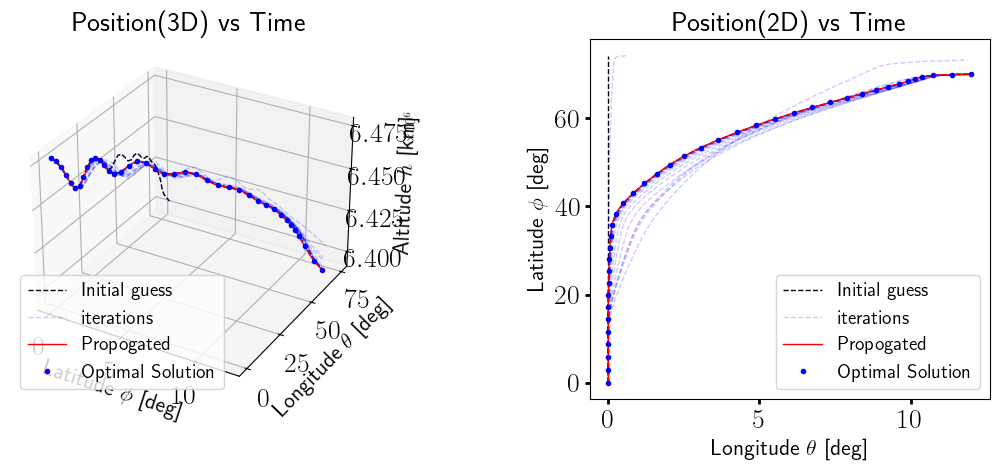

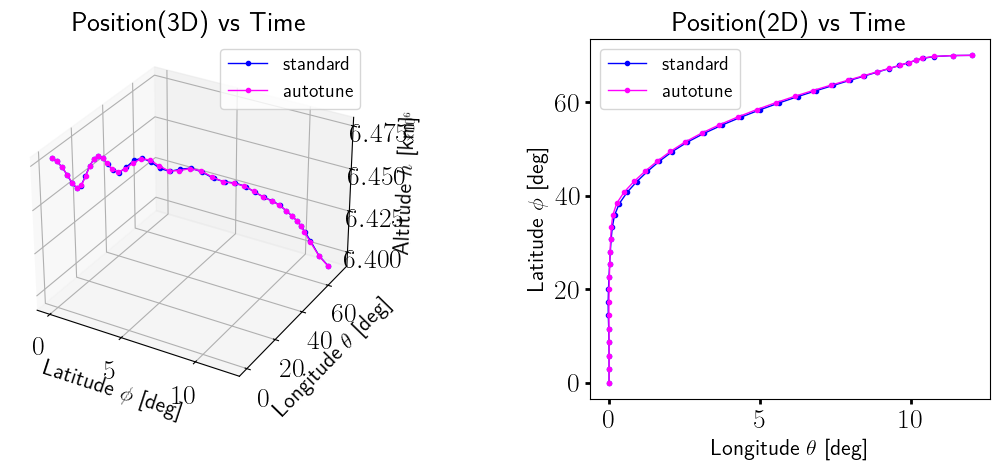

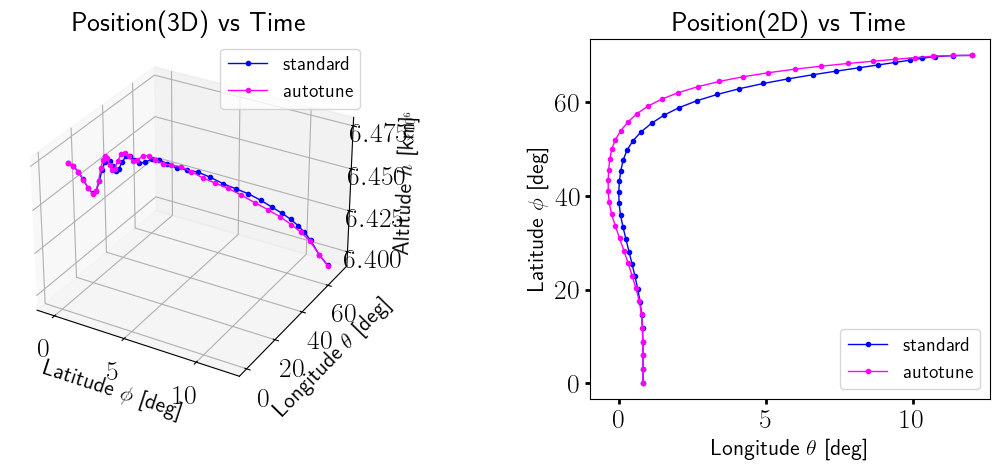

In [12]:
params = {}
params['displayfigs'] = True;
makePlot2(PLTS1,ins={**plotparams,**params});

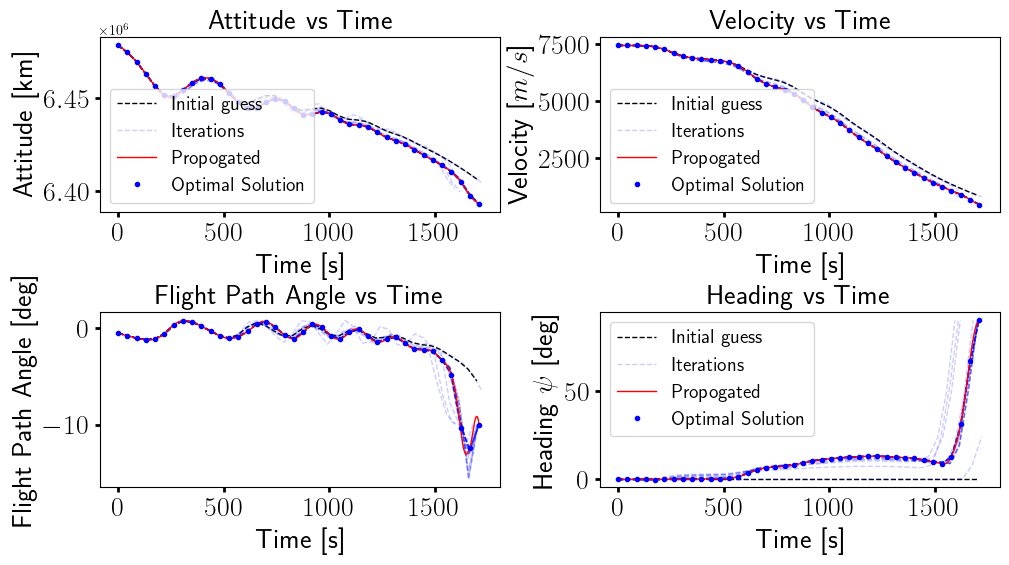

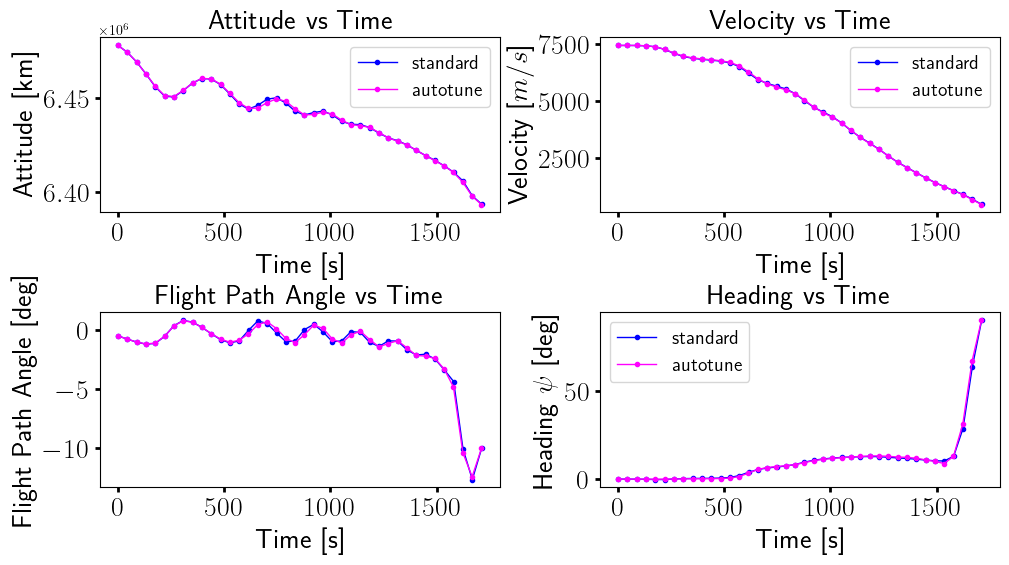

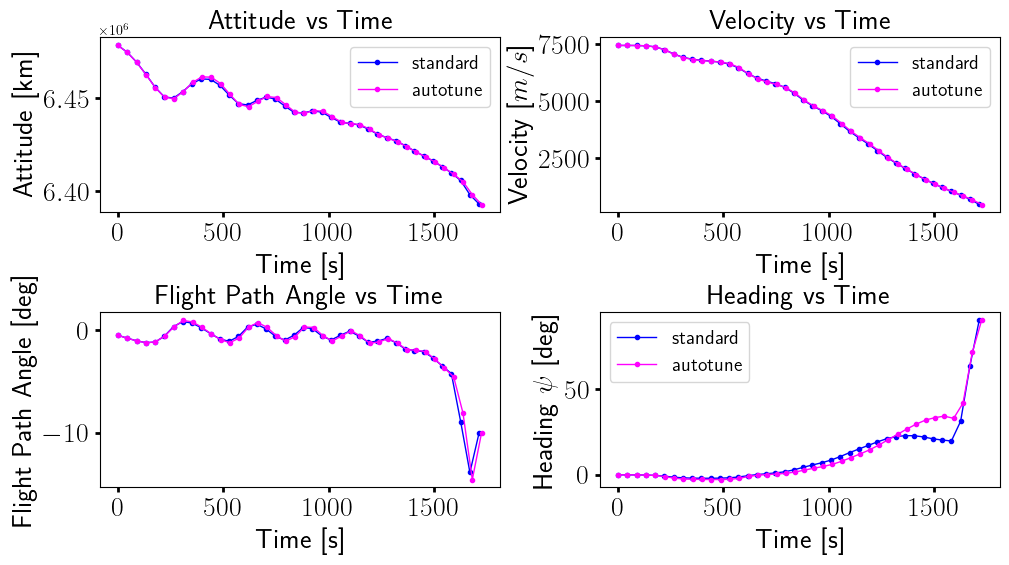

In [8]:
params = {}
figsize = (10,5);
grid = {};
grid[0] = [0.05,0.6,0.4,0.35];  grid[1] = [0.55,0.6,0.4,0.35];
grid[2] = [0.05,0.05,0.4,0.35]; grid[3] = [0.55,0.05,0.4,0.35];
   
titles = {};
ylabels = {};
xlabels = {ind:'Time [s]' for ind in range(4)};
titles[0] = 'Attitude vs Time';
titles[1] = 'Velocity vs Time';
titles[2] = 'Flight Path Angle vs Time';
titles[3] = 'Heading vs Time';

ylabels[0] = 'Attitude [km]';
ylabels[1] = 'Velocity [$m/s$]';    
ylabels[2] = 'Flight Path Angle [deg]';
ylabels[3] = 'Heading $\psi$ [deg]';

params['titleinfo'] = {'fontsize':20,}
params['xlabelinfo'] = {'fontsize':20}
params['ylabelinfo'] = {'fontsize':20}
# params['ticksinfo'] = {'fontsize':20}
# params['legendinfo'] = {'fontsize':2}
params['uselegend'] = [0,1,3];

params['figsize'] = figsize; params['grid'] = grid;
params['titles'] = titles; params['xlabels'] = xlabels; params['ylabels'] = ylabels;
params['displayfigs'] = True;

makePlot3(PLTS1,ins={**plotparams,**params});

In [9]:
# temp = data['scenario1']['autotune']['mc_data'][0]['iters'][2]['weights'];#params']['method']['weights']['W_dyn'];
temp = data['scenario1']['autotune']['mc_data'][0]['iters'][2]['conv_data'];#['chk_feas_ineq'];#params']['method']['weights']['W_dyn'];
# ['w_cost', 'alpha_z', 'alpha_u', 'beta', 'gamma', 'eps_nonzero1',
#  'eps_nonzero2', 'wbuff', 'w_path_scale', 'w_custom_scale', 'w_nfz_scale',
#  'w_dyn_scale', 'w_term_scale',

#  'W_ineq', 'W_term', 'W_dyn', 'W_plus','W_minus',
#  'dual_ineq', 'dual_term', 'dual_dyn', 'dual_plus', 'dual_minus',

#  'wtr_z', 'wtr_u', 'w_fac_N', 'w_fac_Nm1', 'w_ctcs', 'data']


# print(temp)
# print(list(temp))
# print(temp['W_ineq'])

In [10]:

temp = data['scenario1']['autotune']['mc_data'][1]['iters'][-1]['weights'];
# print(temp['weights']['W_ineq'])
print(temp['W_ineq'].shape)
inds = problem.indices.constraints.nonlinear_inequality['path']; #))
# plt.plot(temp['W_ineq'][:,inds])

(40, 5)


In [11]:
# temp = data['scenario1']['autotune']['mc_data'][1]['iters'][-1]['weights'];
# print(list(temp))# print(temp['weights']['W_ineq'])
# print(temp['W_minus_ctcs'])
# print(temp['W_ineq'].shape)
# inds = problem.indices.constraints.nonlinear_inequality['path']; #))
# # plt.plot(temp['W_ineq'][:,inds])

# temp = problem.method.subprob.iter_data[0]['conv_data']

# # print(list(PLTS1.data['scenario1']['method']))

# print(list(temp))
# print(temp['chk_feas_term'])